# CS 4375: Machine Learning – Project Code
## Project Topic: SMS Spam Message Detection Using Deep Learning

Team Members:
- Sejal Patel (SVP220003)
- Jennah Shahein (JXS220148)
- Afiya Syed (AXS220450)

## Step 1: Setup and Imports

In this step, our team is going to set up the basic Python environment that we will use for the rest of the project.

The professor said we are allowed to use libraries for:
- data loading and preprocessing
- evaluation and plotting

but the **core model (LSTM)** and its **training algorithm** must be written by us.

Steps:
- import `numpy` for all numerical operations (used heavily in our from-scratch LSTM),
- import `pandas` for reading and cleaning the SMS dataset,
- import `matplotlib` for plotting training/validation curves later,
- import some functions from `sklearn` for train/test splitting and evaluation metrics,
- set a fixed random seed so our experiments are reproducible (important for our log file later).

In [ ]:
# Step 1: Setup and Imports

# Importing the libraries we needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Make the plots we do show inside notebook
%matplotlib inline

# Set random seed for reproducible results
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully. Random seed set to", RANDOM_SEED)

Libraries imported successfully. Random seed set to 42


## Step 2a: Download the SMS Spam dataset from Kaggle

For development, we are downloading the **SMS Spam Collection** dataset directly from Kaggle using the `kagglehub` library.

Steps:
- Choose any dataset (from Kaggle),
- Do not submit the raw data file with code,
- Host the data on a public link (GitHub).

In [ ]:
# Step 2a – We download the dataset again

import pandas as pd

# the URL for the GitHub RAW
# Jennah's Github will be used
data_file = "https://github.com/jennah99/CS4375-spam-data/raw/refs/heads/main/spam.csv"

print("Using dataset from:", data_file)

Using dataset from: https://github.com/jennah99/CS4375-spam-data/raw/refs/heads/main/spam.csv


## Step 2b: Clean columns and create numeric labels

The CSV from Kaggle has the columns:

- `v1`: label (`ham` or `spam`)
- `v2`: SMS message text
- some extra `Unnamed` columns that are empty

Steps:
1. Keep only the first two useful columns.
2. Rename them to `label` and `text` for clarity.
3. Create a numeric label column `label_num`:
   - `ham` → 0
   - `spam` → 1

In [ ]:
# Step 2b: Load and clean dataset

df = pd.read_csv(data_file, encoding="latin-1")
df.to_csv("spam.csv", index=False, encoding="latin-1")

# Keep only first two columns (label + text) to remove any unnecessary noise and keeps our dataset clean
df = df.iloc[:, :2].copy()
df.columns = ["label", "text"]

# Convert ham/spam to 0/1 becaue the machine can't understand text labels
label_mapping = {"ham": 0, "spam": 1}
df["label_num"] = df["label"].map(label_mapping)

print(df.head())


  label                                               text  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0


## Step 2c: Show class distribution

In [ ]:
# Step 2c: Show the class distribution

print("Class distribution (text labels):")
print(df["label"].value_counts())

print("\nClass distribution (numeric labels 0=ham, 1=spam):")
print(df["label_num"].value_counts())

Class distribution (text labels):
label
ham     4825
spam     747
Name: count, dtype: int64

Class distribution (numeric labels 0=ham, 1=spam):
label_num
0    4825
1     747
Name: count, dtype: int64


## Step 3a: Basic Text Preprocessing: lowercasing & cleaning

Steps:

1. Convert all text to lowercase  
   - Helps lower vocabulary size (“Hello” and “hello” should be the same word)

2. Remove unnecessary spaces in the messages
   
3. Remove numbers/punctuation  
   - However, we will keep punctuation because LSTM models can sometimes learn patterns like “!!!” for spam.

In [ ]:
# Step 3a: Basic text preprocessing

# Convert all text to lowercase
def clean_text(text):
    text = text.lower().strip()
    return text

# Remove extra spaces in the messages
df["clean_text"] = df["text"].apply(clean_text)

print("Sample cleaned text:")
df[["text", "clean_text"]].head()

Sample cleaned text:


,text,clean_text
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


## Step 3b: Tokenize the text into words

Steps:
- Split each SMS message into a list of words using a simple whitespace-based tokenizer
- Do **not** use libraries like NLTK or spaCy because the professor requires that the main algorithm be coded by us from scratch
- Use a basic tokenizer for this model

Example:
- "hey how are you" → ["hey", "how", "are", "you"]

In [ ]:
# Step 3b: Tokenize text into word lists

def tokenize(text):
    return text.split()

df["tokens"] = df["clean_text"].apply(tokenize)

print("Example tokens:")
df[["clean_text", "tokens"]].head()

Example tokens:


,clean_text,tokens
0,"go until jurong point, crazy.. available only ...","[go, until, jurong, point,, crazy.., available..."
1,ok lar... joking wif u oni...,"[ok, lar..., joking, wif, u, oni...]"
2,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,u dun say so early hor... u c already then say...,"[u, dun, say, so, early, hor..., u, c, already..."
4,"nah i don't think he goes to usf, he lives aro...","[nah, i, don't, think, he, goes, to, usf,, he,..."


## Step 3c: Build a vocabulary (word → integer mapping)

To train an LSTM from scratch, the model must operate on integer sequences, not raw text. Therefore, we will need to convert each unique word in the dataset into a unique integer ID.

Steps:

1. Loop through all tokenized messages and count word frequencies.
2. Create a vocabulary dictionary mapping each word → integer index.
3. Reserve two special tokens:
   - `<PAD>` = 0 (used to pad short sequences)
   - `<UNK>` = 1 (used for any word not found in the vocabulary)


In [ ]:
# Step 3c: Build vocabulary (word -> integer ID)

from collections import Counter

# Count all word occurrences
word_counts = Counter()

for tokens in df["tokens"]:
    word_counts.update(tokens)

# Sort words by frequency, so it is cleaner
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

# Create vocabulary dictionary
vocab = {"<PAD>": 0, "<UNK>": 1}

# Assign ID from 2
for idx, (word, count) in enumerate(sorted_words, start=2):
    vocab[word] = idx

print("Vocabulary size:", len(vocab))

Vocabulary size: 13498


## Step 3d: Convert token lists into integer sequences

Steps:
- Convert each SMS message from a list of words into a list of integers.

Example: ["free", "entry", "now"] → [vocab["free"], vocab["entry"], vocab["now"]]

If a word is not found in the vocabulary, map it to the `<UNK>` token (ID = 1).

In [ ]:
# Step 3d: Convert tokens to integer sequences

UNK_ID = vocab["<UNK>"]

def tokens_to_ids(tokens, vocab_dict):
    return [vocab_dict.get(tok, UNK_ID) for tok in tokens]

df["token_ids"] = df["tokens"].apply(lambda toks: tokens_to_ids(toks, vocab))

print("Example token IDs:")
df[["tokens", "token_ids"]].head()

Example token IDs:


,tokens,token_ids
0,"[go, until, jurong, point,, crazy.., available...","[43, 394, 5509, 5510, 5511, 710, 65, 10, 1710,..."
1,"[ok, lar..., joking, wif, u, oni...]","[75, 562, 2547, 395, 7, 3442]"
2,"[free, entry, in, 2, a, wkly, comp, to, win, f...","[56, 409, 10, 22, 5, 711, 983, 2, 168, 2044, 1..."
3,"[u, dun, say, so, early, hor..., u, c, already...","[7, 214, 141, 23, 425, 3446, 7, 155, 237, 61, ..."
4,"[nah, i, don't, think, he, goes, to, usf,, he,...","[1298, 3, 90, 94, 67, 410, 2, 3447, 67, 3448, ..."


## Step 3e: Choose max sequence length and pad/truncate sequences

Steps:
1. Compute the distribution of message lengths (in tokens).
2. Pick a reasonable `MAX_SEQ_LEN` that covers most SMS messages
   (aim to cover most messages without making sequences unnecessarily long).
3. For each message:
   - If it is longer than `MAX_SEQ_LEN`, keep only the first `MAX_SEQ_LEN` tokens.
   - If it is shorter, pad with the `<PAD>` token (ID = 0) at the end.

In [ ]:
# Look at sequence length statistics
seq_lengths = df["token_ids"].apply(len)

print("Min length:", seq_lengths.min())
print("Max length:", seq_lengths.max())
print("Average length:", seq_lengths.mean())

# Some percentiles to see typical lengths
for p in [50, 75, 90, 95, 99]:
    print(f"{p}th percentile length:", seq_lengths.quantile(p / 100.0))


Min length: 1
Max length: 171
Average length: 15.494436468054559
50th percentile length: 12.0
75th percentile length: 23.0
90th percentile length: 29.0
95th percentile length: 33.0
99th percentile length: 54.0


In [ ]:
# Step 3e: Pad/truncate sequences to fixed length

PAD_ID = vocab["<PAD>"]
MAX_SEQ_LEN = 40

def pad_or_truncate(seq, max_len, pad_value=PAD_ID):
    if len(seq) > max_len:
        return seq[:max_len]
    else:
        return seq + [pad_value] * (max_len - len(seq))

df["padded_ids"] = df["token_ids"].apply(lambda s: pad_or_truncate(s, MAX_SEQ_LEN))

# Convert to NumPy arrays
X = np.array(df["padded_ids"].tolist(), dtype=np.int32)
y = df["label_num"].values.astype(np.int32)

print("Input array shape (num_samples, max_seq_len):", X.shape)
print("Labels shape:", y.shape)

# Results
X[0], y[0]

Input array shape (num_samples, max_seq_len): (5572, 40)
Labels shape: (5572,)


(array([  43,  394, 5509, 5510, 5511,  710,   65,   10, 1710,   84,  132,
         441, 3441,  140, 5512, 1489,   87,   52, 5513,  836,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0], dtype=int32),
 np.int32(0))

## Step 3f: Create train, validation, and test splits

Steps:

- Training set: for learning the model parameters
- Validation set: for tuning hyperparameters and monitoring overfitting
- Test set: once at the very end to report final performance

Proportions:

- **70% training**
- **10% validation**
- **20% test**

Steps:
1. Set aside **20%** of the entire dataset for testing.  
2. Take the remaining **80%** and split **12.5%** of it for validation.  
3. Since 12.5% of 80% = **10% of the original dataset**, this gives a clean 70/10/20 split overall.

In [ ]:
# Step 3f: Train/validation/test split

from sklearn.model_selection import train_test_split

# Split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Split off validation set (10% of original)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=RANDOM_SEED,
    stratify=y_train_val,
)

print("Train shape:", X_train.shape, "Labels:", y_train.shape)
print("Val shape:  ", X_val.shape,   "Labels:", y_val.shape)
print("Test shape: ", X_test.shape,  "Labels:", y_test.shape)

# Check balance in each split
def show_split_stats(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"{name} label distribution (0=ham,1=spam):")
    for u, c in zip(unique, counts):
        print(f"  {u}: {c}")
    print()

show_split_stats("Train", y_train)
show_split_stats("Val", y_val)
show_split_stats("Test", y_test)

Train shape: (3899, 40) Labels: (3899,)
Val shape:   (558, 40) Labels: (558,)
Test shape:  (1115, 40) Labels: (1115,)
Train label distribution (0=ham,1=spam):
  0: 3376
  1: 523

Val label distribution (0=ham,1=spam):
  0: 483
  1: 75

Test label distribution (0=ham,1=spam):
  0: 966
  1: 149



## Step 4a: LSTM architecture and hyperparameter choices

Need to implement the LSTM **manually using NumPy**.

Steps:
- Embedding dimension: 50  
  - Each word ID is mapped to a 50-dimensional dense vector.
- LSTM hidden size: 64  
  - The LSTM processes the sequence of embeddings and keeps a hidden state of size 64.
- Output layer: 1 unit with sigmoid  
  - The final hidden state goes through a fully-connected layer and a sigmoid to produce a probability that the SMS is spam.

In [ ]:
# Step 4: Simple LSTM model - Forward Pass

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def tanh(x):
    return np.tanh(x)


class SimpleLSTM:
    def __init__(self, vocab_size, emb_dim=50, hidden_size=64, max_len=40):
        # basic settings
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.hidden_size = hidden_size
        self.max_len = max_len

        # Word embeddings: [vocab_size, emb_dim]
        self.E = 0.01 * np.random.randn(vocab_size, emb_dim)

        # LSTM gate weights
        # shapes:
        #   W? : [hidden_size, emb_dim]
        #   U? : [hidden_size, hidden_size]
        #   b? : [hidden_size]
        self.Wf = 0.1 * np.random.randn(hidden_size, emb_dim)
        self.Uf = 0.1 * np.random.randn(hidden_size, hidden_size)
        self.bf = np.zeros(hidden_size)

        self.Wi = 0.1 * np.random.randn(hidden_size, emb_dim)
        self.Ui = 0.1 * np.random.randn(hidden_size, hidden_size)
        self.bi = np.zeros(hidden_size)

        self.Wc = 0.1 * np.random.randn(hidden_size, emb_dim)
        self.Uc = 0.1 * np.random.randn(hidden_size, hidden_size)
        self.bc = np.zeros(hidden_size)

        self.Wo = 0.1 * np.random.randn(hidden_size, emb_dim)
        self.Uo = 0.1 * np.random.randn(hidden_size, hidden_size)
        self.bo = np.zeros(hidden_size)

        # Output layer: last hidden state -> 1 logit
        self.W_out = 0.1 * np.random.randn(hidden_size)
        self.b_out = 0.0

    def forward(self, X_batch):
        """
        X_batch: [batch_size, max_len] array of token ids.

        Returns:
            probs: [batch_size] array of spam probabilities
            cache: stuff saved for backprop/training later
        """
        batch_size, T = X_batch.shape

        # Lookup embeddings: [batch_size, T, emb_dim]
        emb = self.E[X_batch]

        # Start hidden + cell states at zero
        h = np.zeros((batch_size, self.hidden_size))
        c = np.zeros((batch_size, self.hidden_size))

        h_list = []
        c_list = []
        gate_list = []

        for t in range(T):
            x_t = emb[:, t, :]  # [batch_size, emb_dim]

            # Linear parts
            f_lin = x_t @ self.Wf.T + h @ self.Uf.T + self.bf
            i_lin = x_t @ self.Wi.T + h @ self.Ui.T + self.bi
            c_lin = x_t @ self.Wc.T + h @ self.Uc.T + self.bc
            o_lin = x_t @ self.Wo.T + h @ self.Uo.T + self.bo

            # Activations
            f_t = sigmoid(f_lin)
            i_t = sigmoid(i_lin)
            c_hat = tanh(c_lin)
            o_t = sigmoid(o_lin)

            # Update cell and hidden
            c = f_t * c + i_t * c_hat
            h = o_t * tanh(c)

            h_list.append(h)
            c_list.append(c)
            gate_list.append({
                "x_t": x_t,
                "f_t": f_t, "i_t": i_t, "c_hat": c_hat, "o_t": o_t,
                "f_lin": f_lin, "i_lin": i_lin, "c_lin": c_lin, "o_lin": o_lin
            })

        # Last hidden state
        logits = h @ self.W_out + self.b_out          # [batch_size]
        probs = sigmoid(logits)

        cache = {
            "emb": emb,
            "h_list": h_list,
            "c_list": c_list,
            "gate_list": gate_list,
            "logits": logits,
            "X_batch": X_batch,
        }

        return probs, cache

In [ ]:
# Step 4 Continued: Making sure the forward pass runs

print("X_train shape:", X_train.shape)

# Create a model instance
model = SimpleLSTM(
    vocab_size=len(vocab),
    emb_dim=50,
    hidden_size=64,
    max_len=MAX_SEQ_LEN
)

# Take a small batch from the training set
batch_example = X_train[:4]

# Run forward pass
probs, cache = model.forward(batch_example)

print("Probabilities shape:", probs.shape)
print("Probabilities:", probs)

X_train shape: (3899, 40)
Probabilities shape: (4,)
Probabilities: [0.50088104 0.50088104 0.50088105 0.50088104]


## Step 5a: Loss function

Since this is a binary classification problem (ham = 0, spam = 1), we are using
the standard binary cross-entropy loss. Therefore:

- If the true label is 1 (spam), the model should output a probability close to 1.
- If the true label is 0 (ham), the model should output a probability close to 0.

Steps:
- Take the average loss over all examples
- Add a tiny constant `eps` inside the logs so there is no `log(0)`


In [ ]:
# Step 5a: Binary cross-entropy loss

def binary_cross_entropy(y_true, y_pred):
    """
    y_true: numpy array of shape [batch_size], values 0 or 1
    y_pred: numpy array of shape [batch_size], values between 0 and 1

    returns:
        average loss over the batch (scalar)
    """
    # Avoid log(0)
    eps = 1e-8
    y_pred_clipped = np.clip(y_pred, eps, 1.0 - eps)

    # Compute loss for each example
    loss_vec = - (y_true * np.log(y_pred_clipped) +
                  (1 - y_true) * np.log(1 - y_pred_clipped))

    # Average
    return loss_vec.mean()

## Step 5b: Gradients for the output layer

The last hidden state `h_last` gets turned into a spam prediction through a small linear layer followed by a sigmoid:

    logit = h_last · W_out + b_out
    prob = sigmoid(logit)

Steps:

For binary cross-entropy loss, the gradient of the loss with respect to the
**logits** is:

    dL/dlogit = (prob - y_true)

- error signal that we want to push backward

Then, compute gradients for the output weights:

    dL/dW_out = (dL/dlogit) * h_last
    dL/db_out = dL/dlogit


In [ ]:
# Step 5b: Output layer gradients

def output_layer_backward(cache, y_true, y_pred, model):
    """
    Computes gradients for the small output layer:
        logit = h_last · W_out + b_out

    cache  : dictionary saved from forward pass
    y_true : [batch_size] 0/1 labels
    y_pred : [batch_size] predicted probabilities
    model  : the LSTM model instance containing parameters

    returns:
        grads: dict with dW_out, db_out, and dlogit (to send back into LSTM)
    """

    # Reshape to column vectors
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    # Error signal
    dlogit = (y_pred - y_true)   # shape: [batch]

    # Final hidden state from the forward pass
    h_last = cache["h_list"][-1]   # shape: [batch, hidden_size]

    # Gradients for W_out and b_out
    dW_out = np.sum(h_last * dlogit[:, None], axis=0)
    db_out = np.sum(dlogit)

    grads = {
        "dW_out": dW_out,
        "db_out": db_out,
        "dlogit": dlogit,
    }

    return grads

## Step 5c: Backpropagation through the LSTM (BPTT)

The last hidden state `h_last` is connected to the logits, so the error coming
back into the LSTM at the last time step is based on:

    dL/dh_last = dlogit * W_out

Steps:

- Go from time step T-1 down to 0,
- At each step, use the stored gate values (forget, input, candidate, output),
- Compute how much each gate “contributed” to the loss,
- Accumulate gradients for each gate’s W, U, and b,
- Send gradients back into:
  - the previous hidden state h_{t-1}
  - the previous cell state c_{t-1}
  - the input embedding at time t

In [ ]:
# Step 5c: Backprop through the LSTM (one layer)

def lstm_backward(model, cache, dlogit):
    """
    Backprop through the SimpleLSTM for one batch.

    model  : SimpleLSTM instance (has all the parameters)
    cache  : dictionary from model.forward (contains states and gates)
    dlogit : [batch_size] gradient coming from the output layer
             (this is basically dL/dlogit)
    """

    batch_size = dlogit.shape[0]
    T = model.max_len
    H = model.hidden_size
    D = model.emb_dim

    # Unpack info from cache
    h_list = cache["h_list"]   # list length T, each [batch, H]
    c_list = cache["c_list"]   # list length T, each [batch, H]
    gate_list = cache["gate_list"]  # list length T
    X_batch = cache["X_batch"]      # [batch, T]
    emb = cache["emb"]              # [batch, T, D]

    # Initialize gradients for parameters with zeros
    dE  = np.zeros_like(model.E)

    dWf = np.zeros_like(model.Wf)
    dUf = np.zeros_like(model.Uf)
    dbf = np.zeros_like(model.bf)

    dWi = np.zeros_like(model.Wi)
    dUi = np.zeros_like(model.Ui)
    dbi = np.zeros_like(model.bi)

    dWc = np.zeros_like(model.Wc)
    dUc = np.zeros_like(model.Uc)
    dbc = np.zeros_like(model.bc)

    dWo = np.zeros_like(model.Wo)
    dUo = np.zeros_like(model.Uo)
    dbo = np.zeros_like(model.bo)

    dh_next = dlogit[:, None] * model.W_out[None, :]   # [batch, H]
    dc_next = np.zeros((batch_size, H))

    # Walk backwards
    for t in reversed(range(T)):
        # values at current time step
        gates_t = gate_list[t]
        f_t = gates_t["f_t"]
        i_t = gates_t["i_t"]
        c_hat_t = gates_t["c_hat"]
        o_t = gates_t["o_t"]

        c_t = c_list[t]
        h_t = h_list[t]
        x_t = gates_t["x_t"]

        # previous cell and hidden states
        if t == 0:
            c_prev = np.zeros_like(c_t)
            h_prev = np.zeros_like(h_t)
        else:
            c_prev = c_list[t-1]
            h_prev = h_list[t-1]

        # --- backprop through h_t = o_t * tanh(c_t) ---
        # Total gradient wrt h_t includes gradient from future and from output
        dh = dh_next

        # Gradient wrt output gate
        dtanh_c = (1.0 - np.tanh(c_t) ** 2)
        do_t = dh * np.tanh(c_t)
        dc = dh * o_t * dtanh_c + dc_next

        # --- backprop through c_t = f_t * c_prev + i_t * c_hat_t ---
        df_t = dc * c_prev
        di_t = dc * c_hat_t
        dc_hat_t = dc * i_t

        # Gradient flowing back into c_prev
        dc_prev = dc * f_t

        # --- backprop through activations of gates ---
        # f_t = sigmoid(f_lin), i_t = sigmoid(i_lin), c_hat_t = tanh(c_lin), o_t = sigmoid(o_lin)
        f_lin = gates_t["f_lin"]
        i_lin = gates_t["i_lin"]
        c_lin = gates_t["c_lin"]
        o_lin = gates_t["o_lin"]

        df_lin = df_t * f_t * (1.0 - f_t)
        di_lin = di_t * i_t * (1.0 - i_t)
        dc_lin = dc_hat_t * (1.0 - np.tanh(c_lin) ** 2)
        do_lin = do_t * o_t * (1.0 - o_t)

        # --- gradients for W, U, b of each gate ---
        # shapes:
        #   df_lin: [batch, H], x_t: [batch, D], h_prev: [batch, H]
        dWf += df_lin.T @ x_t
        dUf += df_lin.T @ h_prev
        dbf += df_lin.sum(axis=0)

        dWi += di_lin.T @ x_t
        dUi += di_lin.T @ h_prev
        dbi += di_lin.sum(axis=0)

        dWc += dc_lin.T @ x_t
        dUc += dc_lin.T @ h_prev
        dbc += dc_lin.sum(axis=0)

        dWo += do_lin.T @ x_t
        dUo += do_lin.T @ h_prev
        dbo += do_lin.sum(axis=0)

        #gradient wrt input x_t (for embeddings)
        dx_t = (df_lin @ model.Wf) + \
               (di_lin @ model.Wi) + \
               (dc_lin @ model.Wc) + \
               (do_lin @ model.Wo)     # [batch, D]

        # Update embedding gradients using the token ids at time t
        token_ids = X_batch[:, t]   # [batch]
        for i in range(batch_size):
            dE[token_ids[i]] += dx_t[i]

        # gradient wrt h_prev and c_prev (to pass to previous time step)
        dh_prev = (df_lin @ model.Uf) + \
                  (di_lin @ model.Ui) + \
                  (dc_lin @ model.Uc) + \
                  (do_lin @ model.Uo)

        # Next iteration
        dh_next = dh_prev
        dc_next = dc_prev

    grads_lstm = {
        "dE": dE,
        "dWf": dWf, "dUf": dUf, "dbf": dbf,
        "dWi": dWi, "dUi": dUi, "dbi": dbi,
        "dWc": dWc, "dUc": dUc, "dbc": dbc,
        "dWo": dWo, "dUo": dUo, "dbo": dbo,
    }

    return grads_lstm

## Step 5d: One training step (forward, loss, backprop, update)

Steps:

1. Run the forward pass through my LSTM model to get predictions.
2. Compute the binary cross-entropy loss.
3. Use the output layer backward function to get:
   - gradient for the output weights (W_out, b_out)
   - the error signal `dlogit` that goes back into the LSTM.
4. Run the LSTM backward function (BPTT) to get gradients for:
   - embeddings
   - all LSTM gate weights (Wf, Uf, bf)
5. Update all model parameters using gradient descent with a learning rate.

In [ ]:
# Step 5d: One training step

def train_step(model, X_batch, y_batch, lr=0.001):
    """
    Runs one gradient descent step on a batch.

    model   : SimpleLSTM instance
    X_batch : [batch_size, max_len] input sequences
    y_batch : [batch_size] labels (0/1)
    lr      : learning rate

    returns:
        loss (scalar)
    """

    # 1) forward pass
    y_pred, cache = model.forward(X_batch)

    # 2) compute loss
    loss = binary_cross_entropy(y_batch.astype(np.float32), y_pred)

    # 3) grads for output layer
    out_grads = output_layer_backward(cache, y_batch.astype(np.float32), y_pred, model)

    # 4) grads for LSTM (backprop through time)
    lstm_grads = lstm_backward(model, cache, out_grads["dlogit"])

    # 5) update output layer parameters
    model.W_out -= lr * out_grads["dW_out"]
    model.b_out -= lr * out_grads["db_out"]

    # 6) update LSTM parameters
    model.E  -= lr * lstm_grads["dE"]

    model.Wf -= lr * lstm_grads["dWf"]
    model.Uf -= lr * lstm_grads["dUf"]
    model.bf -= lr * lstm_grads["dbf"]

    model.Wi -= lr * lstm_grads["dWi"]
    model.Ui -= lr * lstm_grads["dUi"]
    model.bi -= lr * lstm_grads["dbi"]

    model.Wc -= lr * lstm_grads["dWc"]
    model.Uc -= lr * lstm_grads["dUc"]
    model.bc -= lr * lstm_grads["dbc"]

    model.Wo -= lr * lstm_grads["dWo"]
    model.Uo -= lr * lstm_grads["dUo"]
    model.bo -= lr * lstm_grads["dbo"]

    return loss

## Step 5e: Full training loop (epochs, mini-batches, accuracy)

Steps:

1. Create a fresh `SimpleLSTM` model.
2. Pick some basic hyperparameters:
   - number of epochs (e.g., 5–10)
   - batch size
   - learning rate
3. For each epoch:
   - shuffle the training data
   - loop over mini-batches
   - call `train_step` on each batch and keep track of the average loss
   - after the epoch, compute accuracy on:
     - training set
     - validation set
4. Output results to see if the loss is going down and accuracy is going up.


In [ ]:
# Step 5e: accuracy helper

def compute_accuracy(model, X_data, y_data, batch_size=128):
    """
    Simple accuracy calculation:
    - run the model on the data in mini-batches
    - threshold probabilities at 0.5
    - compare to true labels
    """
    total = 0
    correct = 0

    n = X_data.shape[0]
    num_batches = int(np.ceil(n / batch_size))

    for b in range(num_batches):
        start = b * batch_size
        end = min((b + 1) * batch_size, n)

        X_batch = X_data[start:end]
        y_batch = y_data[start:end]

        probs, _ = model.forward(X_batch)
        preds = (probs >= 0.5).astype(int)

        total += y_batch.shape[0]
        correct += (preds == y_batch).sum()

    return correct / total

In [ ]:
# Step 5e: Training loop

# Training from scratch
model = SimpleLSTM(
    vocab_size=len(vocab),
    emb_dim=50,
    hidden_size=64,
    max_len=MAX_SEQ_LEN
)

num_epochs = 5
batch_size = 32
learning_rate = 0.001

train_losses = []
train_accs = []
val_accs = []

for epoch in range(1, num_epochs + 1):
    # shuffles training data
    indices = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]

    epoch_loss = 0.0
    n = X_train_shuffled.shape[0]
    num_batches = int(np.ceil(n / batch_size))

    for b in range(num_batches):
        start = b * batch_size
        end = min((b + 1) * batch_size, n)

        X_batch = X_train_shuffled[start:end]
        y_batch = y_train_shuffled[start:end]

        batch_loss = train_step(model, X_batch, y_batch, lr=learning_rate)
        epoch_loss += batch_loss

    # Average loss for this epoch
    epoch_loss /= num_batches
    train_losses.append(epoch_loss)

    # Compute accuracy on full train and validation sets
    train_acc = compute_accuracy(model, X_train, y_train)
    val_acc = compute_accuracy(model, X_val, y_val)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} - "
          f"loss: {epoch_loss:.4f} - "
          f"train_acc: {train_acc:.4f} - "
          f"val_acc: {val_acc:.4f}")

Epoch 1/5 - loss: 0.5218 - train_acc: 0.8659 - val_acc: 0.8656
Epoch 2/5 - loss: 0.4114 - train_acc: 0.8659 - val_acc: 0.8656
Epoch 3/5 - loss: 0.3966 - train_acc: 0.8659 - val_acc: 0.8656
Epoch 4/5 - loss: 0.3948 - train_acc: 0.8659 - val_acc: 0.8656
Epoch 5/5 - loss: 0.3950 - train_acc: 0.8659 - val_acc: 0.8656


## Tables and Plots Requiered

### Experiment Log Table

In [ ]:
# Build log table using the results

import pandas as pd

num_epochs = len(train_losses)

exp_log = pd.DataFrame({
    "Epoch": list(range(1, num_epochs + 1)),
    "Train Loss": train_losses,
    "Train Accuracy": train_accs,
    "Val Accuracy": val_accs
})

exp_log

,Epoch,Train Loss,Train Accuracy,Val Accuracy
0,1,0.521786,0.865863,0.865591
1,2,0.411360,0.865863,0.865591
2,3,0.396579,0.865863,0.865591
3,4,0.394809,0.865863,0.865591
4,5,0.395037,0.865863,0.865591


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
save_path = '/content/drive/MyDrive/CS 4375/CS 4375 Project/output/experiment_log.csv'
exp_log.to_csv(save_path, index=False)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/CS 4375/CS 4375 Project/output/experiment_log.csv


### Matplotlib Plots (Loss Curve + Accuracy Curve)

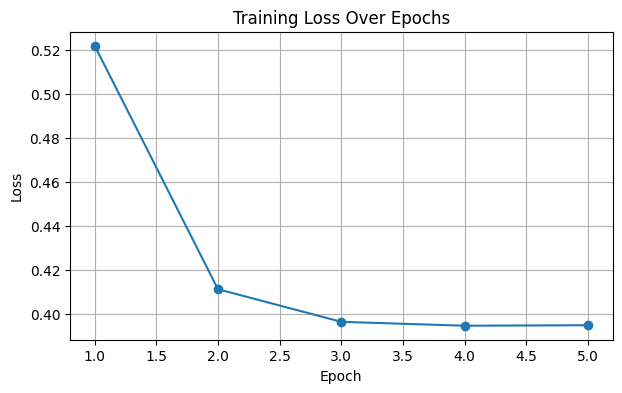

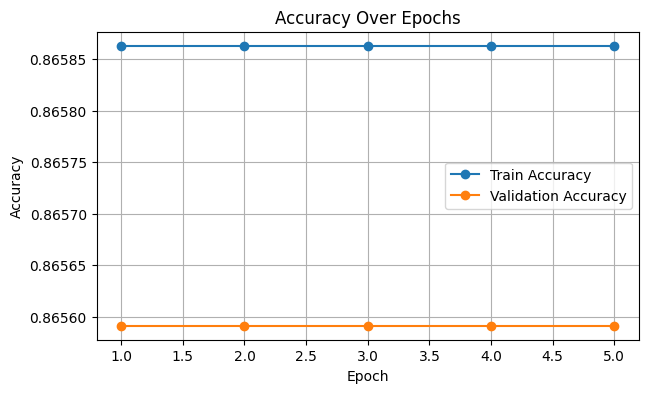

In [ ]:
import matplotlib.pyplot as plt

# Loss Curve
plt.figure(figsize=(7,4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Accuracy Curve (Train + Val)
plt.figure(figsize=(7,4))
plt.plot(range(1, num_epochs + 1), train_accs, marker='o', label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), val_accs, marker='o', label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()